In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import os

def parse_xunit_xml_to_csv(xml_folder, output_csv_path):
    """
    Parses xUnit XML reports and extracts test names, durations, and outcomes.
    """
    extracted_data = []

    # Loop through all XML files in the specified folder
    # (Useful if you download multiple workflow runs)
    for filename in os.listdir(xml_folder):
        if filename.endswith('.xml'):
            file_path = os.path.join(xml_folder, filename)
            
            try:
                tree = ET.parse(file_path)
                root = tree.getroot()

                # xUnit XML stores individual tests under <test> tags
                for test_case in root.iter('test'):
                    test_name = test_case.attrib.get('name', 'Unknown_Test')
                    # xUnit times are in seconds (e.g., 0.045)
                    execution_time = float(test_case.attrib.get('time', 0.0))
                    result = test_case.attrib.get('result', 'Pass') # Pass, Fail, or Skip

                    # Categorize the test type based on its name to make plotting easier later
                    if "Mock" in test_name:
                        test_type = "Mocked_Dependency"
                    elif "Sqlite" in test_name:
                        test_type = "SQLite_InMemory"
                    else:
                        test_type = "Standard_Logic"

                    extracted_data.append({
                        'Run_Source': filename,
                        'Test_Name': test_name,
                        'Test_Type': test_type,
                        'Execution_Time_Seconds': execution_time,
                        'Execution_Time_Milliseconds': execution_time * 1000,
                        'Result': result
                    })
                    
            except ET.ParseError:
                print(f"Error parsing {filename}. Is it a valid XML file?")

    # Convert the list of dictionaries to a Pandas DataFrame
    if extracted_data:
        df = pd.DataFrame(extracted_data)
        
        # Export to CSV
        df.to_csv(output_csv_path, index=False)
        print(f"Successfully extracted {len(df)} test records to {output_csv_path}")
        
        # Print a quick summary to the console
        print("\n--- Quick Summary ---")
        print(df.groupby('Test_Type')['Execution_Time_Milliseconds'].mean().reset_index())
    else:
        print("No test data found. Check your XML files.")

# --- Execution ---
# 1. Create a folder named 'ci_reports' in the same directory as this script.
# 2. Put your downloaded GitHub Actions test_results.xml files in there.
xml_input_directory = './ci_reports'
csv_output_file = 'tdd_execution_dataset.csv'

# Ensure the input directory exists
os.makedirs(xml_input_directory, exist_ok=True)

print(f"Looking for XML files in: {xml_input_directory}")
parse_xunit_xml_to_csv(xml_input_directory, csv_output_file)

Looking for XML files in: ./ci_reports
Successfully extracted 5 test records to tdd_execution_dataset.csv

--- Quick Summary ---
        Test_Type  Execution_Time_Milliseconds
0  Standard_Logic                     227.0395


C:\Users\Admin\AppData\Local\Temp\ipykernel_41352\2950927555.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_41352\2950927555.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


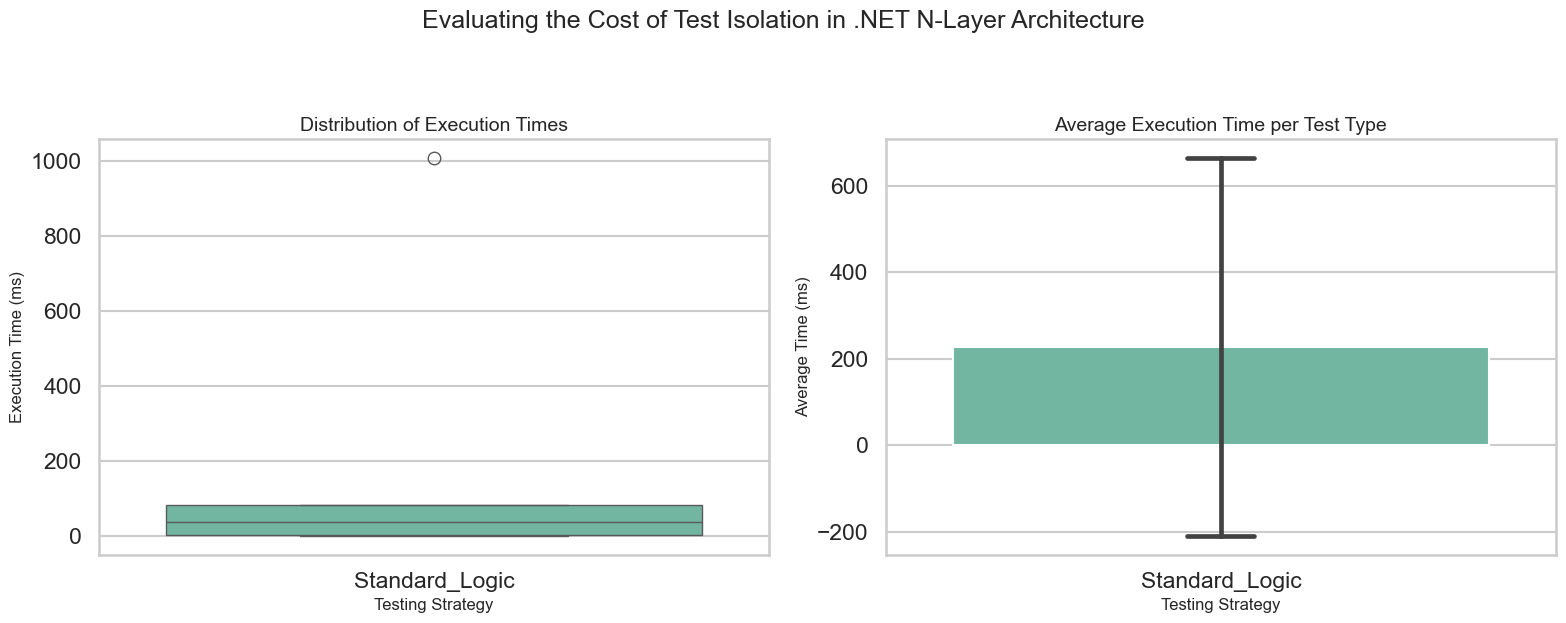

--- Statistical Summary (Average Execution Time) ---
Testing Strategy  Average Time (ms)
  Standard_Logic             227.04


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# Make sure the CSV is in the same directory as your Jupyter Notebook
df = pd.read_csv('tdd_execution_dataset.csv')

# Set the visual style for academic charts
sns.set_theme(style="whitegrid", context="talk")

# 2. Create a Figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Evaluating the Cost of Test Isolation in .NET N-Layer Architecture', fontsize=18, y=1.05)

# --- Chart 1: The Box Plot (Distribution & Variance) ---
# This chart is excellent for showing the spread of execution times 
# and highlighting any outliers (like a particularly slow SQLite boot).
sns.boxplot(
    data=df, 
    x='Test_Type', 
    y='Execution_Time_Milliseconds', 
    ax=axes[0],
    palette="Set2"
)
axes[0].set_title('Distribution of Execution Times', fontsize=14)
axes[0].set_xlabel('Testing Strategy', fontsize=12)
axes[0].set_ylabel('Execution Time (ms)', fontsize=12)

# --- Chart 2: The Bar Plot (Average Execution Time) ---
# This chart clearly communicates the exact "Mocking Penalty" baseline.
sns.barplot(
    data=df, 
    x='Test_Type', 
    y='Execution_Time_Milliseconds', 
    estimator='mean',
    errorbar='sd', # Shows the standard deviation as error bars
    capsize=.1,
    ax=axes[1],
    palette="Set2"
)
axes[1].set_title('Average Execution Time per Test Type', fontsize=14)
axes[1].set_xlabel('Testing Strategy', fontsize=12)
axes[1].set_ylabel('Average Time (ms)', fontsize=12)

# 3. Adjust layout and display
plt.tight_layout()
plt.show()

# 4. Optional: Print the exact statistical averages below the charts
print("--- Statistical Summary (Average Execution Time) ---")
summary = df.groupby('Test_Type')['Execution_Time_Milliseconds'].mean().round(2).reset_index()
summary.columns = ['Testing Strategy', 'Average Time (ms)']
print(summary.to_string(index=False))